In [58]:
import os
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np

In [ ]:
# Configuração do caminho do dataset
# O dataset contém imagens de fundo de olho classificadas em 5 categorias de Retinopatia Diabética:
# - Healthy (Saudável)
# - Mild DR (Retinopatia Leve)
# - Moderate DR (Retinopatia Moderada)
# - Proliferate DR (Retinopatia Proliferativa)
# - Severe DR (Retinopatia Severa)

dataset_path = r"\Dataset"

# Lista todas as classes (subpastas) presentes no diretório do dataset

classes = os.listdir(dataset_path)
counts = []

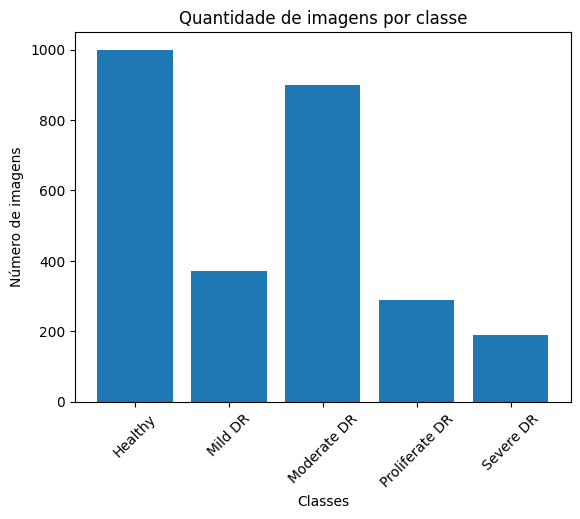

In [ ]:
# Contagem de imagens por classe e visualização

for c in classes:
    class_path = os.path.join(dataset_path, c)
    counts.append(len(os.listdir(class_path)))

plt.bar(classes, counts)
plt.title("Quantidade de imagens por classe")
plt.xlabel("Classes")
plt.ylabel("Número de imagens")
plt.xticks(rotation=45)
plt.show()

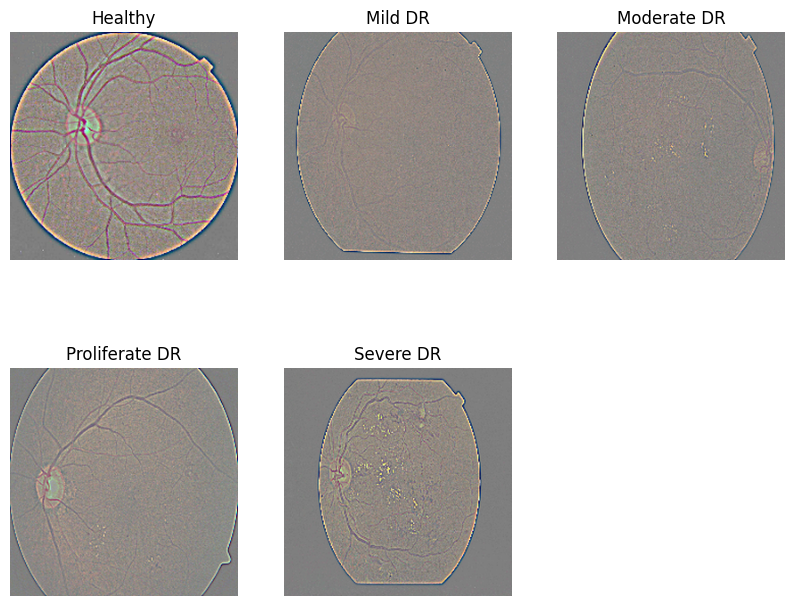

In [ ]:
# Visualização de amostras aleatórias de imagens por classe
# Objetivo: inspecionar visualmente a qualidade e características das imagens do dataset

plt.figure(figsize=(10,8))

for i, c in enumerate(classes):
    class_path = os.path.join(dataset_path, c)
    img_name = random.choice(os.listdir(class_path))
    
    img_path = os.path.join(class_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.show()

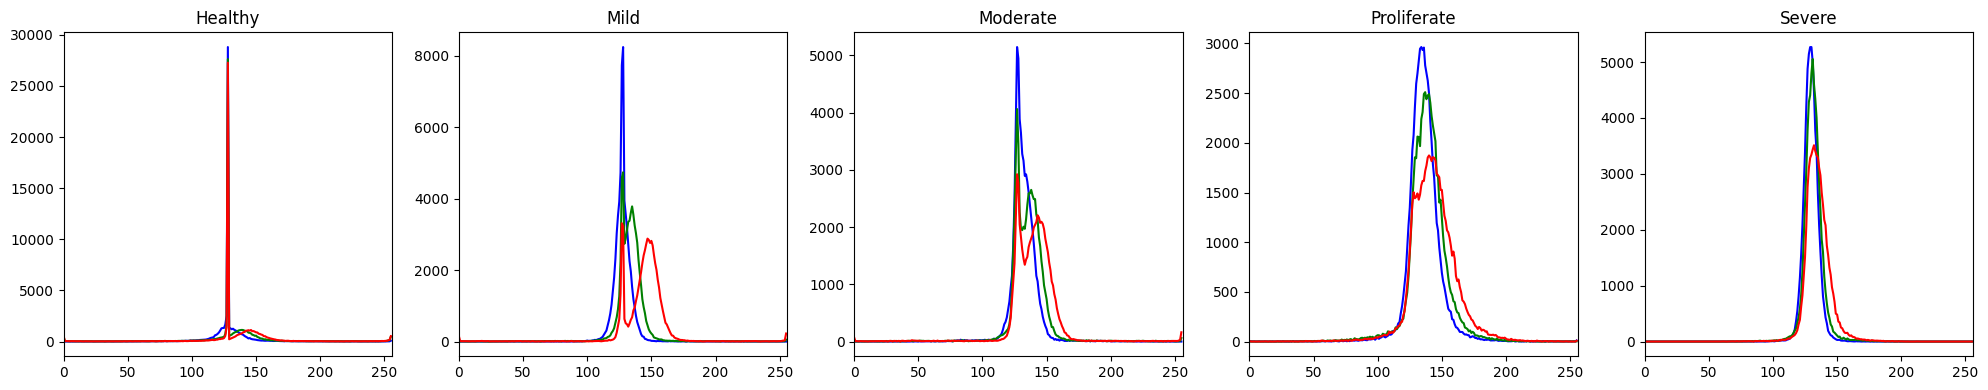

In [ ]:
# Análise dos histogramas de cor por classe
# O histograma mostra a distribuição de intensidade dos pixels nos canais R, G e B

img_healthy = cv2.imread(r"C:\Users\mortal\Documents\programa\para dados\dados_ia\Dataset\Healthy\Healthy_20.png")
img_Mild = cv2.imread(r"C:\Users\mortal\Documents\programa\para dados\dados_ia\Dataset\Mild DR\Mild_DR_20.png")
img_Moderate = cv2.imread(r"C:\Users\mortal\Documents\programa\para dados\dados_ia\Dataset\Moderate DR\Moderate_DR_20.png")
img_Proliferate = cv2.imread(r"C:\Users\mortal\Documents\programa\para dados\dados_ia\Dataset\Proliferate DR\Proliferate DR_20.png")
img_Severe = cv2.imread(r"C:\Users\mortal\Documents\programa\para dados\dados_ia\Dataset\Severe DR\Severe DR_20.png")

imgs = [img_healthy, img_Mild, img_Moderate, img_Proliferate, img_Severe]
titles = ["Healthy", "Mild", "Moderate", "Proliferate", "Severe"]

color = ('b','g','r')

plt.figure(figsize=(20,4))

for j, img in enumerate(imgs):

    plt.subplot(1,5,j+1)  # 1 linha, 5 colunas

    for i, col in enumerate(color):
        hist = cv2.calcHist([img],[i],None,[256],[0,256])
        plt.plot(hist,color=col)

    plt.title(titles[j])
    plt.xlim([0,256])

plt.tight_layout()
plt.show()

In [ ]:
# Análise estatística de características visuais por classe
# Para cada classe, calcula métricas que descrevem as propriedades das imagens:
# - Brilho médio: intensidade média dos pixels em escala de cinza
# - Contraste médio: desvio padrão da intensidade (maior valor = mais contraste)
# - Bordas: densidade de bordas detectadas pelo algoritmo Canny
# - Cor média: valor médio de cada canal (R, G, B)

for classe in os.listdir(dataset_path):
    
    class_path = os.path.join(dataset_path, classe)
    
    brightness_values = []
    contrast_values = []
    edges_values = []

    red_values = []
    green_values = []
    blue_values = []

    for img_name in os.listdir(class_path):
        
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        brightness = np.mean(gray)
        contrast = np.std(gray)

        edges = cv2.Canny(gray,50,150)
        mean_color = img.mean(axis=(0,1))
        blue, green, red = mean_color

        brightness_values.append(brightness)
        contrast_values.append(contrast)
        edges_values.append(edges)

        red_values.append(red)
        green_values.append(green)
        blue_values.append(blue)

    print('-'*50)
    print(classe, "brilho médio:", np.mean(brightness_values))
    print(classe, "contraste médio:", np.mean(contrast_values))
    print(classe, "bordas médio:", np.mean(edges_values))

    print("Cor média:")
    print("R:", np.mean(red_values))
    print("G:", np.mean(green_values))
    print("B:", np.mean(blue_values))

--------------------------------------------------
Healthy brilho médio: 134.93817645263672
Healthy contraste médio: 21.118162664792244
Healthy bordas médio: 39.739973373413086
Cor média:
R: 139.38116766357422
G: 133.7669922027588
B: 129.30653427124022
--------------------------------------------------
Mild DR brilho médio: 135.55685218604836
Mild DR contraste médio: 14.74684139639203
Mild DR bordas médio: 25.533168071025127
Cor média:
R: 141.10929581925674
G: 134.02126238023914
B: 128.90201444883604
--------------------------------------------------
Moderate DR brilho médio: 135.5457227918837
Moderate DR contraste médio: 14.564881404197493
Moderate DR bordas médio: 24.986631266276042
Cor média:
R: 140.45991104125977
G: 134.19864379882813
B: 129.58517120361327
--------------------------------------------------
Proliferate DR brilho médio: 135.20170582738416
Proliferate DR contraste médio: 14.226060317070012
Proliferate DR bordas médio: 25.273772404111664
Cor média:
R: 139.8328407024515